# Comparacao de Janela IMU: Kimodo vs Real

Este notebook plota uma janela da IMU sintetica (Kimodo) contra a IMU real para a mesma captura.

Fluxo:
1. Selecionar captura (dominio, usuario, tag).
2. Selecionar a janela do Kimodo (por indice).
3. Recortar a IMU real no mesmo intervalo temporal.
4. Reamostrar a IMU real para os timestamps da janela Kimodo.
5. Plotar comparacao por eixo (x, y, z).

In [19]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'pose_module').exists() and (p / 'output').exists()), None)
if PROJECT_ROOT is None:
    raise RuntimeError('Nao foi possivel localizar a raiz do projeto. Abra o notebook dentro do repositorio IMUGPT.')

print('Project root:', PROJECT_ROOT)

Project root: /home/henriquesouza/IMUGPT


In [20]:
# Captura alvo
DOMAIN = '10ms'
USER_ID = 5
TAG_NUMBER = 2

# Janela Kimodo
WINDOW_INDEX = 5  # 0 = primeira janela

# Sinal
SIGNAL_GROUP = 'acc'  # 'acc' ou 'gyro'
SENSOR_NAME = 'right_forearm'

# Paths
MIXED_MANIFEST = PROJECT_ROOT / 'output' / 'exp_mixed_pose' / 'mixed_virtual_imu_manifest.jsonl'
WINDOW_CATALOG = PROJECT_ROOT / 'output' / 'robot_emotions_qwen_windows' / 'kimodo_window_prompt_catalog.jsonl'
REAL_IMU_ROOT = PROJECT_ROOT / 'output' / 'exp_real_pose'

In [21]:
SENSOR_ID_TO_NAME = {1: 'waist', 2: 'head', 3: 'left_forearm', 4: 'right_forearm'}
CHANNEL_LABELS = {'acc': ('ax', 'ay', 'az'), 'gyro': ('gx', 'gy', 'gz')}
UNIT = {'acc': 'm/s^2', 'gyro': 'rad/s'}


def clip_id_for(domain: str, user_id: int, tag_number: int) -> str:
    return f'robot_emotions_{domain}_u{user_id:02d}_tag{tag_number:02d}'


def load_window_timing(window_catalog: Path, reference_clip_id: str) -> dict[str, dict]:
    timing = {}
    with window_catalog.open() as fh:
        for raw in fh:
            entry = json.loads(raw)
            if entry.get('reference_clip_id') == reference_clip_id:
                timing[entry['window_id']] = entry['window']
    return timing


def load_kimodo_windows(mixed_manifest: Path, reference_clip_id: str, window_timing: dict[str, dict]) -> list[dict]:
    windows = []
    with mixed_manifest.open() as fh:
        for raw in fh:
            entry = json.loads(raw)
            if entry.get('pose_kind') != 'synthetic':
                continue
            if entry.get('reference_clip_id') != reference_clip_id:
                continue

            wid = entry.get('window_id', '')
            npz_path = Path(entry['virtual_imu_artifacts']['virtual_imu_npz_path'])
            if not npz_path.exists():
                continue

            timing = window_timing.get(wid, {})
            windows.append({
                'window_id': wid,
                'start_sec': float(timing.get('start_sec', 0.0)),
                'end_sec': float(timing.get('end_sec', entry.get('duration_sec', 5.0))),
                'npz_path': npz_path,
            })

    windows.sort(key=lambda w: (w['start_sec'], w['window_id']))
    return windows


def load_real_imu(real_imu_root: Path, domain: str, user_id: int, reference_clip_id: str, signal_key: str):
    user_folder = f'user_{user_id:02d}'
    npz_path = real_imu_root / domain / user_folder / reference_clip_id / 'imu.npz'
    if not npz_path.exists():
        raise FileNotFoundError(f'IMU real nao encontrada: {npz_path}')

    with np.load(npz_path, allow_pickle=True) as d:
        imu = np.asarray(d['imu'], dtype=np.float32)
        ts = np.asarray(d['timestamps_sec'], dtype=np.float32)
        sensor_ids = [int(x) for x in d['sensor_ids'].tolist()]

    sl = slice(0, 3) if signal_key == 'acc' else slice(3, 6)
    sensor_names = [SENSOR_ID_TO_NAME.get(sid, f'sensor_{sid}') for sid in sensor_ids]
    return ts, imu[:, :, sl], sensor_names


def resample_to_target_time(source_t: np.ndarray, source_v: np.ndarray, target_t: np.ndarray) -> np.ndarray:
    # source_v shape: (T, C)
    out = np.zeros((target_t.shape[0], source_v.shape[1]), dtype=np.float32)
    for c in range(source_v.shape[1]):
        out[:, c] = np.interp(target_t, source_t, source_v[:, c])
    return out

In [22]:
reference_clip = clip_id_for(DOMAIN, USER_ID, TAG_NUMBER)
print('Clip:', reference_clip)

window_timing = load_window_timing(WINDOW_CATALOG, reference_clip)
windows = load_kimodo_windows(MIXED_MANIFEST, reference_clip, window_timing)
if not windows:
    raise RuntimeError('Nenhuma janela Kimodo encontrada para esta captura.')

if WINDOW_INDEX < 0 or WINDOW_INDEX >= len(windows):
    raise IndexError(f'WINDOW_INDEX={WINDOW_INDEX} invalido. Total de janelas: {len(windows)}')

selected_window = windows[WINDOW_INDEX]
print('Window selecionada:', selected_window['window_id'])
print('Intervalo:', selected_window['start_sec'], '->', selected_window['end_sec'])

with np.load(selected_window['npz_path'], allow_pickle=True) as d:
    kimodo_ts = np.asarray(d['timestamps_sec'], dtype=np.float32) + selected_window['start_sec']
    kimodo_sig = np.asarray(d[SIGNAL_GROUP], dtype=np.float32)
    kimodo_sensors = [str(s) for s in d['sensor_names'].tolist()]

if SENSOR_NAME not in kimodo_sensors:
    raise ValueError(f'Sensor {SENSOR_NAME} nao existe na janela Kimodo. Disponiveis: {kimodo_sensors}')

kimodo_sensor_idx = kimodo_sensors.index(SENSOR_NAME)
kimodo_sensor_values = kimodo_sig[:, kimodo_sensor_idx, :]

real_ts, real_sig, real_sensors = load_real_imu(REAL_IMU_ROOT, DOMAIN, USER_ID, reference_clip, SIGNAL_GROUP)
if SENSOR_NAME not in real_sensors:
    raise ValueError(f'Sensor {SENSOR_NAME} nao existe na IMU real. Disponiveis: {real_sensors}')

real_sensor_idx = real_sensors.index(SENSOR_NAME)
real_sensor_values = real_sig[:, real_sensor_idx, :]

# Recorta o intervalo real que cobre a janela Kimodo
t0, t1 = float(kimodo_ts[0]), float(kimodo_ts[-1])
mask = (real_ts >= t0) & (real_ts <= t1)
if mask.sum() < 2:
    raise RuntimeError('Poucos pontos na IMU real dentro da janela para interpolacao.')

real_ts_window = real_ts[mask]
real_values_window = real_sensor_values[mask]

# Reamostra real nos timestamps Kimodo
real_resampled = resample_to_target_time(real_ts_window, real_values_window, kimodo_ts)

print('Kimodo window shape:', kimodo_sensor_values.shape)
print('Real window shape (raw cut):', real_values_window.shape)
print('Real window shape (resampled):', real_resampled.shape)

Clip: robot_emotions_10ms_u05_tag02
Window selecionada: robot_emotions_10ms_u05_tag02__w005
Intervalo: 12.5 -> 17.5
Kimodo window shape: (150, 3)
Real window shape (raw cut): (553, 3)
Real window shape (resampled): (150, 3)


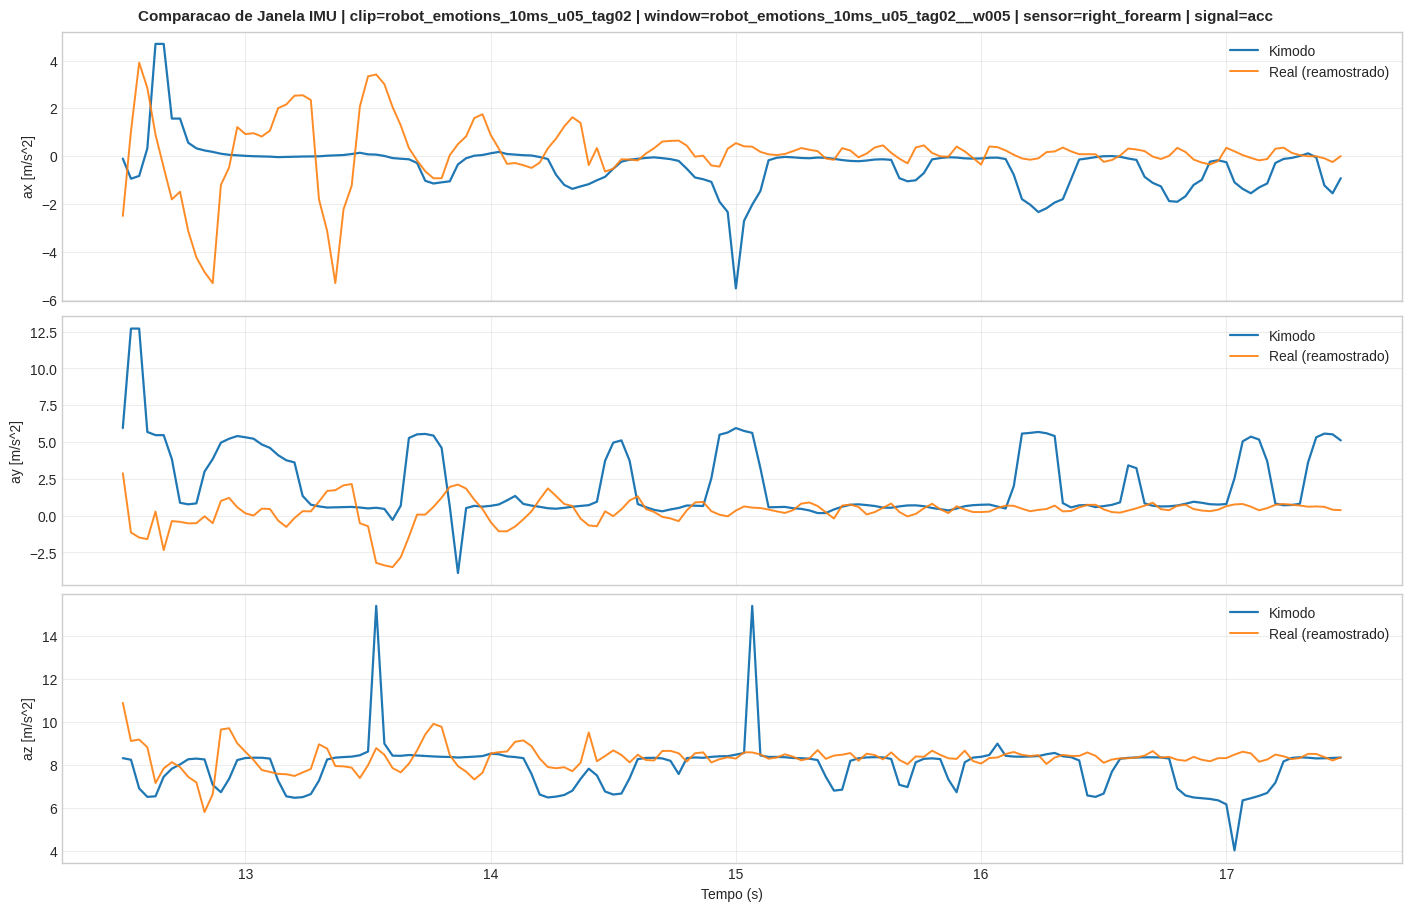

In [23]:
labels = CHANNEL_LABELS[SIGNAL_GROUP]
unit = UNIT[SIGNAL_GROUP]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)

for i in range(3):
    axes[i].plot(kimodo_ts, kimodo_sensor_values[:, i], label='Kimodo', linewidth=1.6)
    axes[i].plot(kimodo_ts, real_resampled[:, i], label='Real (reamostrado)', linewidth=1.4, alpha=0.9)
    axes[i].set_ylabel(f'{labels[i]} [{unit}]')
    axes[i].grid(True, alpha=0.35)
    axes[i].legend(loc='upper right')

axes[2].set_xlabel('Tempo (s)')
fig.suptitle(
    f'Comparacao de Janela IMU | clip={reference_clip} | window={selected_window["window_id"]} | sensor={SENSOR_NAME} | signal={SIGNAL_GROUP}',
    fontsize=11,
    fontweight='bold'
)
plt.show()

In [24]:
# Metricas simples por eixo
for i, axis_name in enumerate(labels):
    err = kimodo_sensor_values[:, i] - real_resampled[:, i]
    rmse = float(np.sqrt(np.mean(err ** 2)))
    corr = float(np.corrcoef(kimodo_sensor_values[:, i], real_resampled[:, i])[0, 1])
    print(f'{axis_name}: RMSE={rmse:.5f} | Corr={corr:.4f}')

ax: RMSE=1.80522 | Corr=-0.0703
ay: RMSE=3.29141 | Corr=-0.1299
az: RMSE=1.32498 | Corr=0.1128
